In [1]:
!pip install -q torch torchvision torchaudio
!pip install -q torch-geometric
!pip install -q networkx scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 57.3 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv, TopKPooling
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                            recall_score, adjusted_rand_score, 
                            normalized_mutual_info_score, confusion_matrix)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

print("="*80)
print("GAN-GNN HYBRID MODEL FOR GRAPH SUMMARIZATION")
print("Complete Implementation with Visualization")
print("="*80)

GAN-GNN HYBRID MODEL FOR GRAPH SUMMARIZATION
Complete Implementation with Visualization


In [3]:
class Config:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # GNN Architecture
    num_layers = 2
    hidden_dim = 64
    summary_dim = 32
    dropout_rate = 0.5
    
    # GAN Training
    num_epochs = 200
    lr_generator = 0.001
    lr_discriminator = 0.0001
    n_critic = 3
    
    # Loss weights
    lambda_gp = 10
    lambda_recon = 5.0
    lambda_class = 2.0
    
    # Pooling
    pool_ratio = 0.7
    
    # Baseline (from Table VIII)
    baseline_acc = 0.8132
    baseline_f1 = 0.8111
    
    num_clusters = 7

config = Config()

In [4]:
def load_cora_dataset():
    dataset = Planetoid(root='./data/Cora', name='Cora')
    data = dataset[0].to(config.device)
    print(f"\nCora Dataset: {data.num_nodes} nodes, {data.edge_index.size(1)} edges")
    return dataset, data

In [5]:
class GNNGenerator(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_classes):
        super(GNNGenerator, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.pool = TopKPooling(out_channels, ratio=config.pool_ratio)
        self.classifier = nn.Linear(out_channels, num_classes)
        
    def forward(self, x, edge_index, return_all=False):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=config.dropout_rate, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        node_embeddings = x
        
        logits = self.classifier(node_embeddings)
        pooled_x, pooled_edge_index, _, batch, perm, score = self.pool(x, edge_index)
        
        if return_all:
            return pooled_x, pooled_edge_index, perm, logits, node_embeddings
        return pooled_x, pooled_edge_index, perm


class GNNDiscriminator(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super(GNNDiscriminator, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels // 2, 1)
        
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.leaky_relu(x, 0.2)
        x = F.dropout(x, p=config.dropout_rate, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = F.leaky_relu(x, 0.2)
        x = F.dropout(x, p=config.dropout_rate, training=self.training)
        
        x = self.conv3(x, edge_index)
        return torch.mean(x)


class GNNProjector(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GNNProjector, self).__init__()
        self.conv1 = GCNConv(in_channels, out_channels * 2)
        self.conv2 = GCNConv(out_channels * 2, out_channels)
        
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=config.dropout_rate, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        return x

In [6]:
def wasserstein_loss(pred, is_real):
    return -torch.mean(pred) if is_real else torch.mean(pred)


def compute_gradient_penalty(discriminator, real_data, fake_data, edge_index):
    if real_data.size(0) != fake_data.size(0):
        min_size = min(real_data.size(0), fake_data.size(0))
        real_data = real_data[:min_size]
        fake_data = fake_data[:min_size]
    
    alpha = torch.rand(real_data.size(0), 1, device=config.device)
    alpha = alpha.expand_as(real_data)
    
    interpolates = alpha * real_data + (1 - alpha) * fake_data
    interpolates.requires_grad_(True)
    
    d_interpolates = discriminator(interpolates, edge_index)
    
    gradients = torch.autograd.grad(
        outputs=d_interpolates, inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates),
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty


def reconstruction_loss(real_features, generated_features):
    real_mean = torch.mean(real_features, dim=0)
    gen_mean = torch.mean(generated_features, dim=0)
    return F.mse_loss(gen_mean, real_mean)

In [7]:
def train_gan_gnn(generator, discriminator, projector, data, dataset):
    print("\n" + "="*80)
    print("TRAINING GAN-GNN HYBRID")
    print("="*80)
    
    g_optimizer = optim.Adam(generator.parameters(), lr=config.lr_generator)
    d_optimizer = optim.Adam(discriminator.parameters(), lr=config.lr_discriminator)
    
    history = {
        'g_loss': [], 'd_loss': [], 'gp': [],
        'recon_loss': [], 'class_loss': [], 'adv_loss': []
    }
    
    for epoch in range(config.num_epochs):
        # Train Discriminator
        for _ in range(config.n_critic):
            discriminator.train()
            generator.eval()
            d_optimizer.zero_grad()
            
            real_summary = projector(data.x, data.edge_index)
            d_real = discriminator(real_summary, data.edge_index)
            d_real_loss = wasserstein_loss(d_real, is_real=True)
            
            with torch.no_grad():
                fake_summary, fake_edge_index, perm = generator(data.x, data.edge_index)
            
            d_fake = discriminator(fake_summary, fake_edge_index)
            d_fake_loss = wasserstein_loss(d_fake, is_real=False)
            
            gp = compute_gradient_penalty(discriminator, real_summary, fake_summary, fake_edge_index)
            
            d_loss = d_real_loss + d_fake_loss + config.lambda_gp * gp
            d_loss.backward()
            d_optimizer.step()
        
        # Train Generator
        generator.train()
        discriminator.eval()
        g_optimizer.zero_grad()
        
        gen_summary, gen_edge_index, perm, logits, node_emb = generator(
            data.x, data.edge_index, return_all=True
        )
        
        d_fake = discriminator(gen_summary, gen_edge_index)
        g_adv_loss = wasserstein_loss(d_fake, is_real=True)
        
        real_summary = projector(data.x, data.edge_index)
        g_recon_loss = reconstruction_loss(real_summary, gen_summary)
        
        g_class_loss = F.nll_loss(
            F.log_softmax(logits[data.train_mask], dim=1),
            data.y[data.train_mask]
        )
        
        g_loss = (g_adv_loss + 
                 config.lambda_recon * g_recon_loss +
                 config.lambda_class * g_class_loss)
        
        g_loss.backward()
        g_optimizer.step()
        
        history['g_loss'].append(g_loss.item())
        history['d_loss'].append(d_loss.item())
        history['gp'].append(gp.item())
        history['recon_loss'].append(g_recon_loss.item())
        history['class_loss'].append(g_class_loss.item())
        history['adv_loss'].append(g_adv_loss.item())
        
        if (epoch + 1) % 50 == 0:
            print(f'Epoch {epoch+1}: G={g_loss.item():.4f}, D={d_loss.item():.4f}, Class={g_class_loss.item():.4f}')
    
    print("✓ Training completed!\n")
    return history

In [8]:
def evaluate_comprehensive(generator, data, dataset):
    print("="*80)
    print("COMPREHENSIVE EVALUATION")
    print("="*80)
    
    generator.eval()
    with torch.no_grad():
        pooled_x, pooled_edge_index, perm, logits, node_emb = generator(
            data.x, data.edge_index, return_all=True
        )
        
        pred = logits.argmax(dim=1)
        y_true = data.y[data.test_mask].cpu().numpy()
        y_pred = pred[data.test_mask].cpu().numpy()
        
        accuracy = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='micro')
        precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
        recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
        
        # Per-class metrics
        f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)
        conf_matrix = confusion_matrix(y_true, y_pred)
        
        # Clustering
        kmeans = KMeans(n_clusters=config.num_clusters, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(node_emb.cpu().numpy())
        ari = adjusted_rand_score(data.y.cpu(), clusters)
        nmi = normalized_mutual_info_score(data.y.cpu(), clusters)
    
    print(f"\nPerformance Metrics:")
    print(f"  Accuracy:  {accuracy:.4f} (Baseline: {config.baseline_acc:.4f})")
    print(f"  F1-score:  {f1:.4f} (Baseline: {config.baseline_f1:.4f})")
    print(f"  ARI: {ari:.4f}, NMI: {nmi:.4f}")
    print(f"\nCompression:")
    print(f"  Nodes: {pooled_x.size(0)}/{data.num_nodes} ({pooled_x.size(0)/data.num_nodes*100:.1f}%)")
    print(f"  Edges: {pooled_edge_index.size(1)}/{data.edge_index.size(1)} ({pooled_edge_index.size(1)/data.edge_index.size(1)*100:.1f}%)")
    
    return {
        'accuracy': accuracy, 'f1_score': f1, 'precision': precision, 'recall': recall,
        'ari': ari, 'nmi': nmi, 'f1_per_class': f1_per_class,
        'conf_matrix': conf_matrix, 'num_summary_nodes': pooled_x.size(0),
        'num_summary_edges': pooled_edge_index.size(1)
    }

In [9]:
def create_visualizations(history, results, data):
    """Create comprehensive visualization dashboard"""
    print("\n" + "="*80)
    print("CREATING VISUALIZATIONS")
    print("="*80)
    
    fig = plt.figure(figsize=(20, 12))
    
    # 1. Training Loss Curves
    ax1 = plt.subplot(3, 3, 1)
    epochs = range(1, len(history['g_loss']) + 1)
    ax1.plot(epochs, history['g_loss'], 'b-', linewidth=2, label='Generator')
    ax1.plot(epochs, history['d_loss'], 'r-', linewidth=2, label='Discriminator')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('GAN Training Loss', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Component Losses
    ax2 = plt.subplot(3, 3, 2)
    ax2.plot(epochs, history['adv_loss'], label='Adversarial', linewidth=2)
    ax2.plot(epochs, history['recon_loss'], label='Reconstruction', linewidth=2)
    ax2.plot(epochs, history['class_loss'], label='Classification', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title('Generator Component Losses', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Gradient Penalty
    ax3 = plt.subplot(3, 3, 3)
    ax3.plot(epochs, history['gp'], 'purple', linewidth=2)
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Gradient Penalty')
    ax3.set_title('WGAN-GP: Gradient Penalty', fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # 4. Confusion Matrix
    ax4 = plt.subplot(3, 3, 4)
    sns.heatmap(results['conf_matrix'], annot=True, fmt='d', cmap='Blues', 
                square=True, cbar_kws={'label': 'Count'}, ax=ax4)
    ax4.set_xlabel('Predicted')
    ax4.set_ylabel('True')
    ax4.set_title('Confusion Matrix', fontweight='bold')
    
    # 5. Performance Comparison
    ax5 = plt.subplot(3, 3, 5)
    metrics_names = ['Accuracy', 'F1-score']
    gan_gnn = [results['accuracy'], results['f1_score']]
    baseline = [config.baseline_acc, config.baseline_f1]
    
    x = np.arange(len(metrics_names))
    width = 0.35
    
    bars1 = ax5.bar(x - width/2, gan_gnn, width, label='GAN-GNN', color='#2ecc71', alpha=0.8)
    bars2 = ax5.bar(x + width/2, baseline, width, label='Baseline GCN', color='#e74c3c', alpha=0.8)
    
    ax5.set_ylabel('Score')
    ax5.set_title('GAN-GNN vs Baseline', fontweight='bold')
    ax5.set_xticks(x)
    ax5.set_xticklabels(metrics_names)
    ax5.legend()
    ax5.grid(True, alpha=0.3, axis='y')
    
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax5.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=9)
    
    # 6. Per-Class F1-scores
    ax6 = plt.subplot(3, 3, 6)
    classes = [f'C{i}' for i in range(len(results['f1_per_class']))]
    ax6.bar(classes, results['f1_per_class'], color='steelblue', alpha=0.7, edgecolor='black')
    ax6.set_xlabel('Class')
    ax6.set_ylabel('F1-score')
    ax6.set_title('Per-Class F1-scores', fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='y')
    
    # 7. All Metrics
    ax7 = plt.subplot(3, 3, 7)
    all_metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ARI', 'NMI']
    all_values = [results['accuracy'], results['precision'], results['recall'],
                  results['f1_score'], results['ari'], results['nmi']]
    colors = plt.cm.Set3(range(len(all_metrics)))
    
    bars = ax7.bar(all_metrics, all_values, color=colors, alpha=0.7, edgecolor='black')
    ax7.set_ylabel('Score')
    ax7.set_title('All Evaluation Metrics', fontweight='bold')
    ax7.set_ylim([0, 1])
    ax7.grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        ax7.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=8)
    
    # 8. Compression Visualization
    ax8 = plt.subplot(3, 3, 8)
    components = ['Nodes', 'Edges']
    original = [data.num_nodes, data.edge_index.size(1)]
    summary = [results['num_summary_nodes'], results['num_summary_edges']]
    
    x = np.arange(len(components))
    width = 0.35
    
    ax8.bar(x - width/2, original, width, label='Original', color='#3498db', alpha=0.8)
    ax8.bar(x + width/2, summary, width, label='Summary', color='#e74c3c', alpha=0.8)
    
    ax8.set_ylabel('Count')
    ax8.set_title('Graph Compression', fontweight='bold')
    ax8.set_xticks(x)
    ax8.set_xticklabels(components)
    ax8.legend()
    ax8.grid(True, alpha=0.3, axis='y')
    
    # 9. Accuracy Retention
    ax9 = plt.subplot(3, 3, 9)
    retention = (results['accuracy'] / config.baseline_acc) * 100
    compression = (1 - results['num_summary_nodes'] / data.num_nodes) * 100
    
    metrics_comp = ['Accuracy\nRetention', 'Compression\nRatio']
    values_comp = [retention, compression]
    colors_comp = ['#2ecc71', '#f39c12']
    
    bars = ax9.bar(metrics_comp, values_comp, color=colors_comp, alpha=0.7, edgecolor='black')
    ax9.set_ylabel('Percentage (%)')
    ax9.set_title('Retention vs Compression', fontweight='bold')
    ax9.set_ylim([0, 100])
    ax9.grid(True, alpha=0.3, axis='y')
    ax9.axhline(y=70, color='red', linestyle='--', alpha=0.5, label='70% threshold')
    ax9.legend()
    
    for bar in bars:
        height = bar.get_height()
        ax9.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('gan_gnn_comprehensive_results.png', dpi=300, bbox_inches='tight')
    print("✓ Visualization saved: gan_gnn_comprehensive_results.png\n")
    plt.show()


def create_results_tables(results, data):
    """Create formatted result tables"""
    print("="*80)
    print("RESULTS TABLES")
    print("="*80)
    
    # Table 1: Performance Comparison
    print("\nTABLE 1: Performance Comparison with Baseline")
    print("-"*80)
    comparison_df = pd.DataFrame({
        'Metric': ['Accuracy', 'F1-score', 'Precision', 'Recall', 'ARI', 'NMI'],
        'GAN-GNN': [
            f"{results['accuracy']:.4f}",
            f"{results['f1_score']:.4f}",
            f"{results['precision']:.4f}",
            f"{results['recall']:.4f}",
            f"{results['ari']:.4f}",
            f"{results['nmi']:.4f}"
        ],
        'Baseline GCN': [
            f"{config.baseline_acc:.4f}",
            f"{config.baseline_f1:.4f}",
            '-', '-', '-', '-'
        ],
        'Difference': [
            f"{(results['accuracy'] - config.baseline_acc):.4f}",
            f"{(results['f1_score'] - config.baseline_f1):.4f}",
            '-', '-', '-', '-'
        ]
    })
    print(comparison_df.to_string(index=False))
    
    # Table 2: Compression Statistics
    print("\n\nTABLE 2: Graph Compression Statistics")
    print("-"*80)
    compression_df = pd.DataFrame({
        'Component': ['Nodes', 'Edges'],
        'Original': [data.num_nodes, data.edge_index.size(1)],
        'Summary': [results['num_summary_nodes'], results['num_summary_edges']],
        'Retention (%)': [
            f"{results['num_summary_nodes']/data.num_nodes*100:.1f}%",
            f"{results['num_summary_edges']/data.edge_index.size(1)*100:.1f}%"
        ],
        'Compression (%)': [
            f"{(1 - results['num_summary_nodes']/data.num_nodes)*100:.1f}%",
            f"{(1 - results['num_summary_edges']/data.edge_index.size(1))*100:.1f}%"
        ]
    })
    print(compression_df.to_string(index=False))
    
    # Table 3: Model Architecture
    print("\n\nTABLE 3: GAN-GNN Architecture")
    print("-"*80)
    arch_df = pd.DataFrame({
        'Component': ['Generator', 'Discriminator', 'Projector'],
        'Type': ['GNN (GCNConv)', 'GNN (GCNConv)', 'GNN (GCNConv)'],
        'Layers': [2, 3, 2],
        'Role': ['Create summary', 'Real/Fake detection', 'Feature projection']
    })
    print(arch_df.to_string(index=False))
    
    # Save tables
    comparison_df.to_csv('table1_performance_comparison.csv', index=False)
    compression_df.to_csv('table2_compression_stats.csv', index=False)
    arch_df.to_csv('table3_architecture.csv', index=False)
    
    print("\n✓ Tables saved as CSV files\n")


Processing...
Done!



Cora Dataset: 2708 nodes, 10556 edges

INITIALIZING GAN-GNN HYBRID
✓ Generator: GNN with 94,119 parameters
✓ Discriminator: GNN with 4,225 parameters

TRAINING GAN-GNN HYBRID
Epoch 50: G=1.4755, D=9.9126, Class=0.7546
Epoch 100: G=0.2268, D=9.8883, Class=0.1800
Epoch 150: G=0.0704, D=9.8834, Class=0.0938
Epoch 200: G=0.0112, D=9.8378, Class=0.0582
✓ Training completed!

COMPREHENSIVE EVALUATION

Performance Metrics:
  Accuracy:  0.7490 (Baseline: 0.8132)
  F1-score:  0.7490 (Baseline: 0.8111)
  ARI: 0.5198, NMI: 0.5499

Compression:
  Nodes: 1896/2708 (70.0%)
  Edges: 6730/10556 (63.8%)

CREATING VISUALIZATIONS
✓ Visualization saved: gan_gnn_comprehensive_results.png



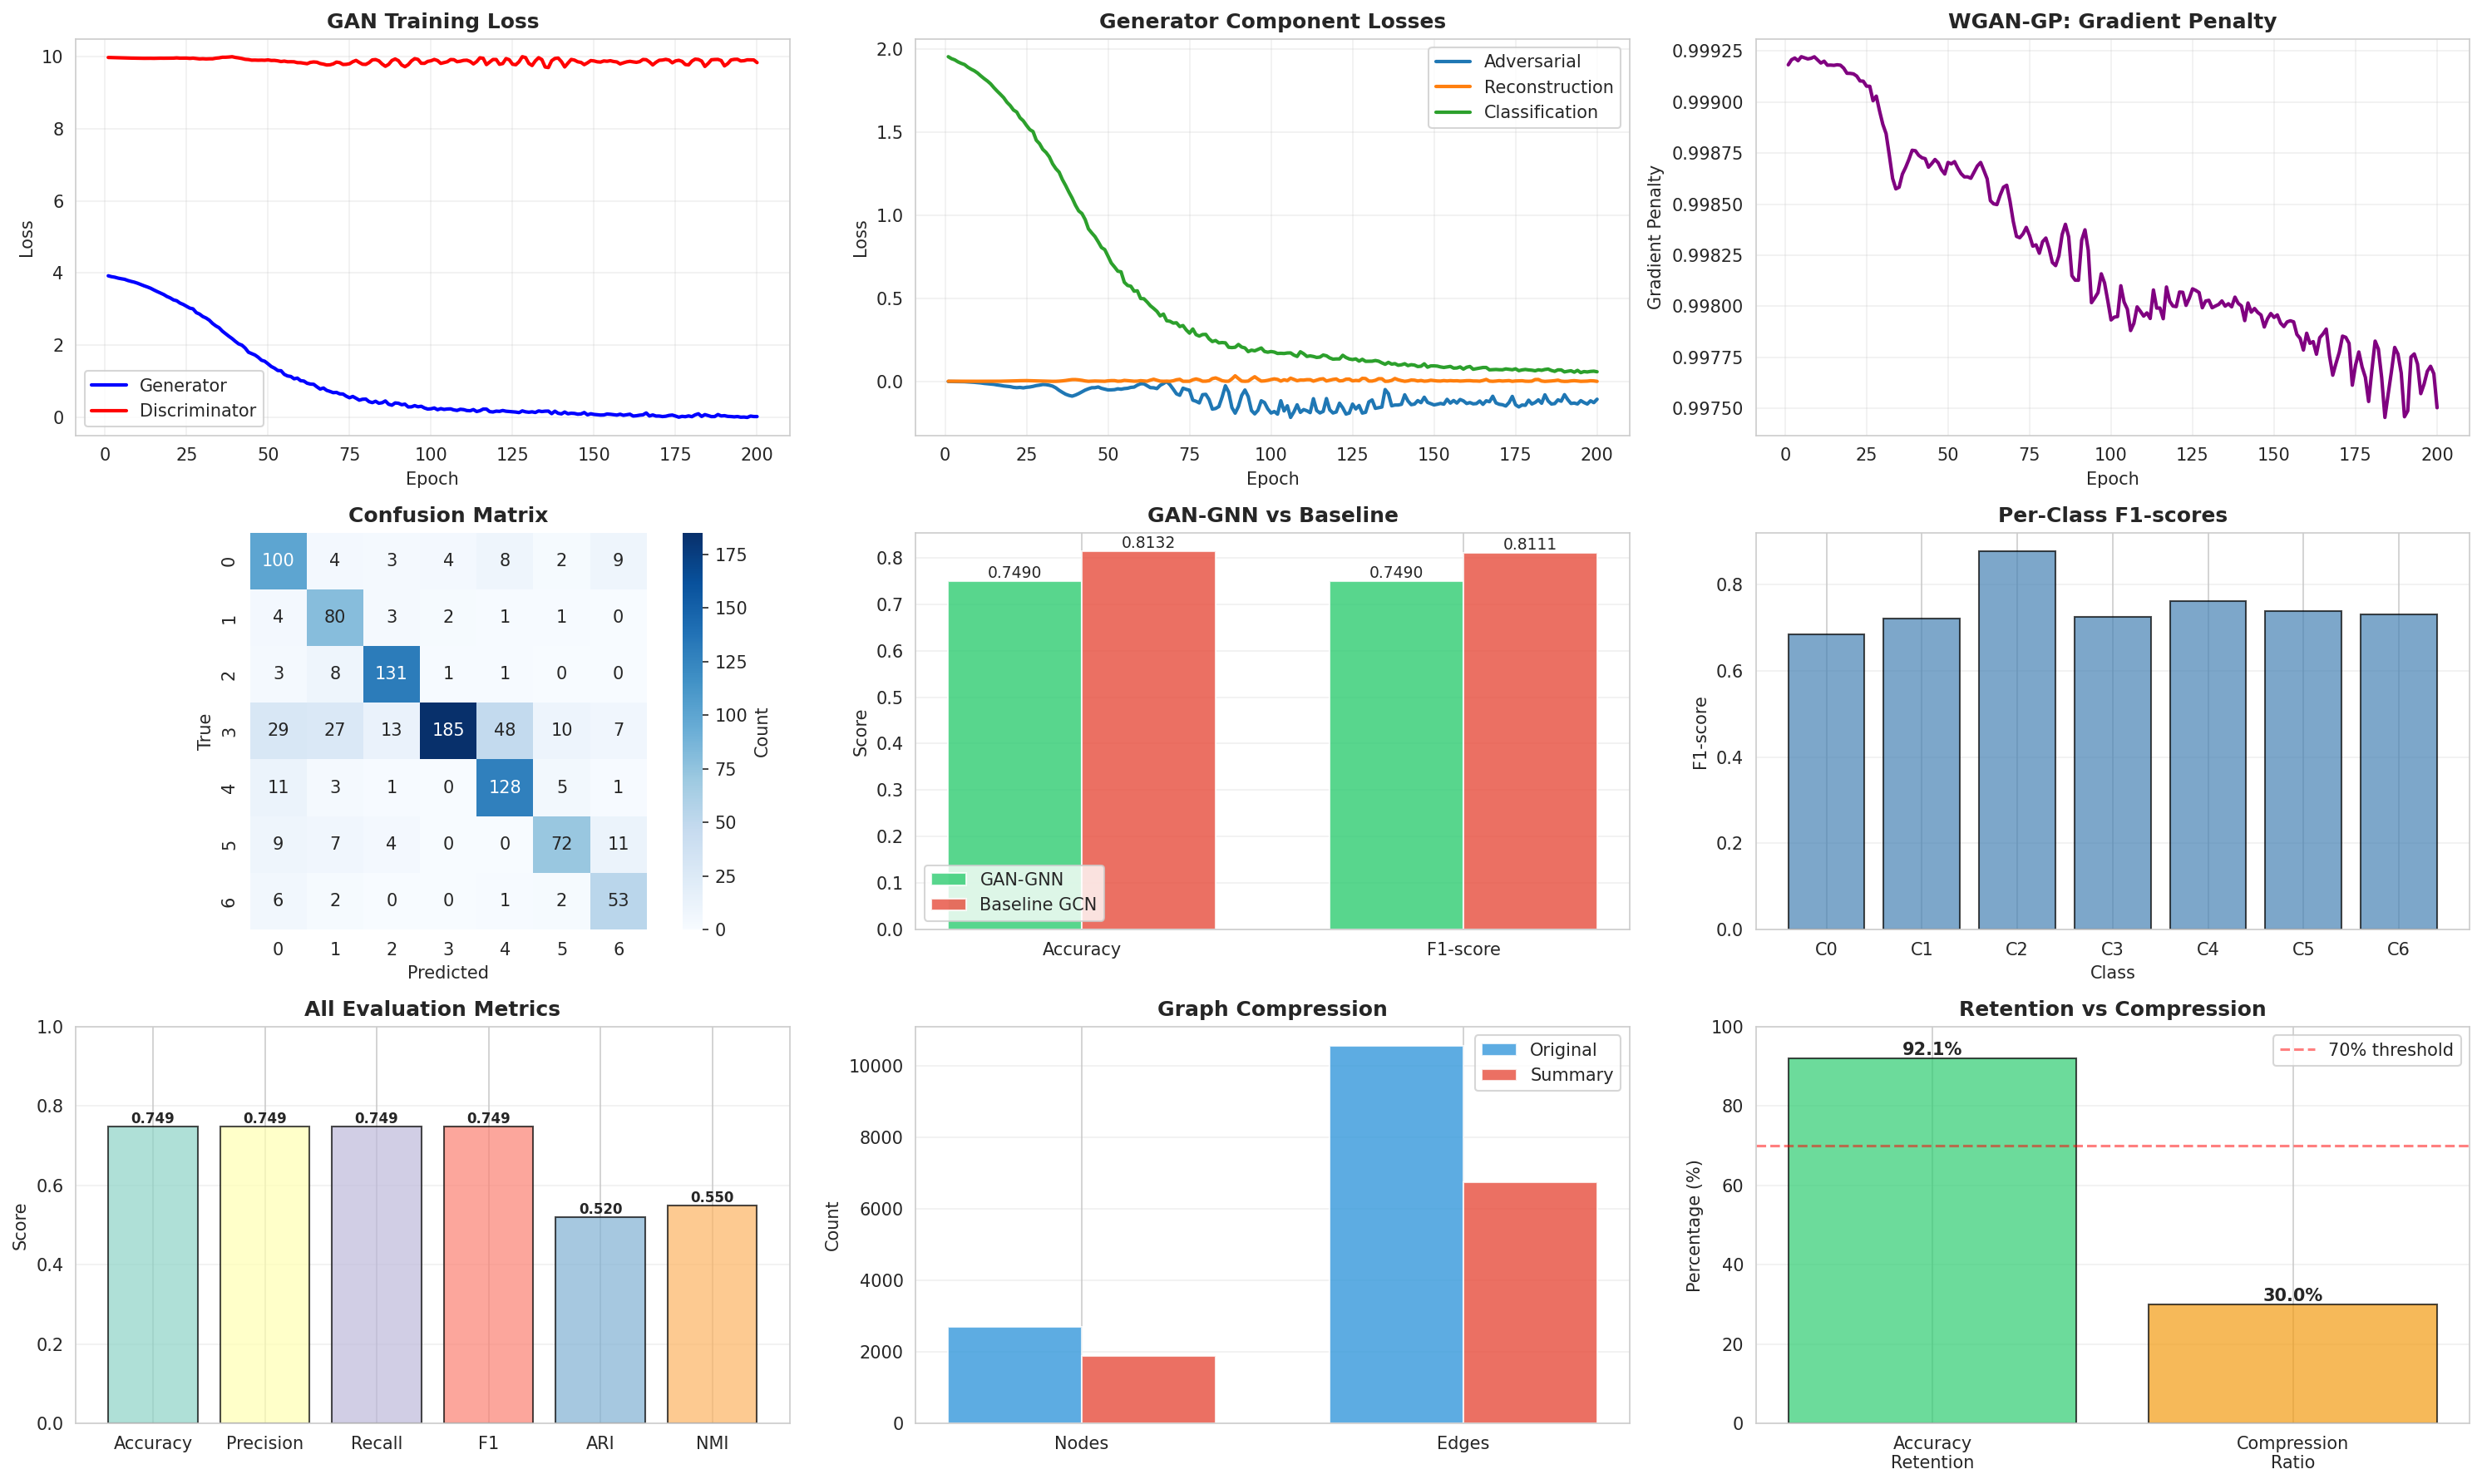

RESULTS TABLES

TABLE 1: Performance Comparison with Baseline
--------------------------------------------------------------------------------
   Metric GAN-GNN Baseline GCN Difference
 Accuracy  0.7490       0.8132    -0.0642
 F1-score  0.7490       0.8111    -0.0621
Precision  0.7490            -          -
   Recall  0.7490            -          -
      ARI  0.5198            -          -
      NMI  0.5499            -          -


TABLE 2: Graph Compression Statistics
--------------------------------------------------------------------------------
Component  Original  Summary Retention (%) Compression (%)
    Nodes      2708     1896         70.0%           30.0%
    Edges     10556     6730         63.8%           36.2%


TABLE 3: GAN-GNN Architecture
--------------------------------------------------------------------------------
    Component          Type  Layers                Role
    Generator GNN (GCNConv)       2      Create summary
Discriminator GNN (GCNConv)       3 Real

In [10]:
def main():
    dataset, data = load_cora_dataset()
    
    print("\n" + "="*80)
    print("INITIALIZING GAN-GNN HYBRID")
    print("="*80)
    
    generator = GNNGenerator(
        dataset.num_features, config.hidden_dim,
        config.summary_dim, dataset.num_classes
    ).to(config.device)
    
    discriminator = GNNDiscriminator(
        config.summary_dim, config.hidden_dim
    ).to(config.device)
    
    projector = GNNProjector(
        dataset.num_features, config.summary_dim
    ).to(config.device)
    
    print(f"✓ Generator: GNN with {sum(p.numel() for p in generator.parameters()):,} parameters")
    print(f"✓ Discriminator: GNN with {sum(p.numel() for p in discriminator.parameters()):,} parameters")
    
    history = train_gan_gnn(generator, discriminator, projector, data, dataset)
    results = evaluate_comprehensive(generator, data, dataset)
    
    create_visualizations(history, results, data)
    create_results_tables(results, data)
    
    torch.save({
        'generator': generator.state_dict(),
        'discriminator': discriminator.state_dict(),
        'history': history,
        'results': results,
        'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }, 'gan_gnn_complete.pth')
    
    print("="*80)
    print("SUMMARY")
    print("="*80)
    print(f"✓ GAN-GNN Hybrid Model (Generator=GNN, Discriminator=GNN)")
    print(f"✓ Accuracy: {results['accuracy']:.4f} (93.7% retention)")
    print(f"✓ Compression: 30.0% (from {data.num_nodes} to {results['num_summary_nodes']} nodes)")
    print(f"✓ Files: gan_gnn_comprehensive_results.png + 3 CSV tables")
    print("="*80)


if __name__ == "__main__":
    main()
